# Categorical Probability Distribution

## 1. Definition

A probability is assigned to each of a set of discrete unordered outcomes.

## 2. Intuition

<span style="color:red;">**Out of several mutually exclusive categories, which one occurs?** </span>

The categorical distribution is the natural extension of Bernoulli from two outcomes to K outcomes.

**Bernoulli**: $$Y \epsilon \{0,1\}$$

**Categorical**: $$Y \epsilon \{0, 1, 2, ... , K-1 \}$$

**with a probability vector**: $$\theta = [\theta_0, \theta_1, ..., \theta_{K-1}]$$

**such that**: $$\theta_k \geq 0, \quad \displaystyle\sum_{k=0}^{K-1}\theta_k = 1$$ 

## 3. Parameter

The distribution is parametrized by the probabilities assigned to each event. We define $\theta_k$ to be the probability assigned to outcome $k$. 
The set of $\theta_k$’s are the parameters, and are constrained by $$\displaystyle\sum_{k=0}^{K-1}\theta_k = 1$$

## 4. Support

If we index the categories with sequential integers from 1 to N, the distribution is supported for integers 1 to N, inclusive when described using the indices of the categories.

## 5. Probability Mass Function

The simplest form is: $$P(Y=k)=\theta_k$$

There is also one-hot form: if $$y = [y_0, ..., y_k]$$

contains exactly one 1, then, $$P(Y=y) = \prod_{k=0}^{K-1}\theta_k^{y_k}$$

## 6. Cumulative Distribution Function


$$F(k) = P(Y \leq k) = \sum_{i=0}^{k}\theta_i$$

## 7. Moments

Moments are not defined for a Categorical distribution because the value of $k$ is not necessarily numeric.

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib as plt

In [97]:
class Categorical:
    """
    Categorical distribution over K categories indexed as:

        0, 1, ..., K - 1
    """

    def __init__(self, theta):
        theta = np.asarray(theta, dtype=float)

        if theta.ndim != 1:
            raise ValueError("theta must be a one-dimensional probability vector.")

        if theta.size == 0:
            raise ValueError("theta cannot be empty.")

        if not np.all(theta >= 0):
            raise ValueError("Every probability in theta must be non-negative.")

        if not np.isclose(np.sum(theta), 1.0):
            raise ValueError("The probabilities in theta must sum to 1.")

        self.theta = theta
        self.K = theta.size
        self.support = np.arange(self.K)

    def pmf(self, n):
        """
        Probability mass function:

            P(Y = n) = theta[n]

        Values outside the support receive probability 0.
        """

        n = np.asarray(n)

        P = np.zeros_like(n, dtype=float)

        valid = (
            (n >= 0)
            & (n < self.K)
            & (n == np.floor(n))
        )

        indices = n[valid].astype(int)

        P[valid] = self.theta[indices]

        return P

    def cdf(self, n):
        """
        Cumulative distribution function:

            F(n) = P(Y <= n)

        The CDF is defined using the numerical ordering
        of category indices 0, 1, ..., K - 1.
        """

        n = np.asarray(n)

        F = np.zeros_like(n, dtype=float)

        # Above the largest category, all probability has accumulated.
        F[n >= self.K - 1] = 1.0

        # Values between 0 and K - 1
        valid = (n >= 0) & (n < self.K - 1)

        cumulative_probabilities = np.cumsum(self.theta)

        indices = np.floor(n[valid]).astype(int)

        F[valid] = cumulative_probabilities[indices]

        return F

    def sample(self, size=1, random_state=None):

        rng = np.random.default_rng(random_state)

        uniform_samples = rng.random(size)
        print(uniform_samples)
        cumulative_probabilities = np.cumsum(self.theta)

        return np.searchsorted(cumulative_probabilities, uniform_samples)

    def plot(self, figsize=(10, 4)):
        """
        Plot the PMF and CDF of the Categorical distribution.
        """
    
        import matplotlib.pyplot as plt
    
        support = self.support
    
        pmf = self.pmf(support)
        cdf = self.cdf(support)
    
        fig, ax = plt.subplots(1, 2, figsize=figsize)
    
        # ---------------- PMF ----------------
        ax[0].bar(support, pmf)
    
        ax[0].set_title("Categorical PMF")
        ax[0].set_xlabel("Category")
        ax[0].set_ylabel("Probability")
        ax[0].set_xticks(support)
        ax[0].grid(True, axis="y")
    
        # ---------------- CDF ----------------
        ax[1].step(support, cdf, where="post")
    
        ax[1].set_title("Categorical CDF")
        ax[1].set_xlabel("Category")
        ax[1].set_ylabel("Cumulative Probability")
        ax[1].set_xticks(support)
        ax[1].set_ylim(0, 1.05)
        ax[1].grid(True)
    
        plt.tight_layout()
        plt.show()

In [98]:
distribution = Categorical(
    theta=[0.4, 0.3, 0.2, 0.1]
)

In [99]:
print(distribution.pmf(1))

0.3


In [100]:
print(distribution.cdf([-1, 0, 0.5, 1, 1.7, 2, 3, 4]))

[0.  0.4 0.4 0.7 0.7 0.9 1.  1. ]


In [96]:
distribution.sample(size=5)

[0.86057805 0.05446475 0.80053819 0.41464314 0.58578276]


array([2, 0, 2, 1, 1])

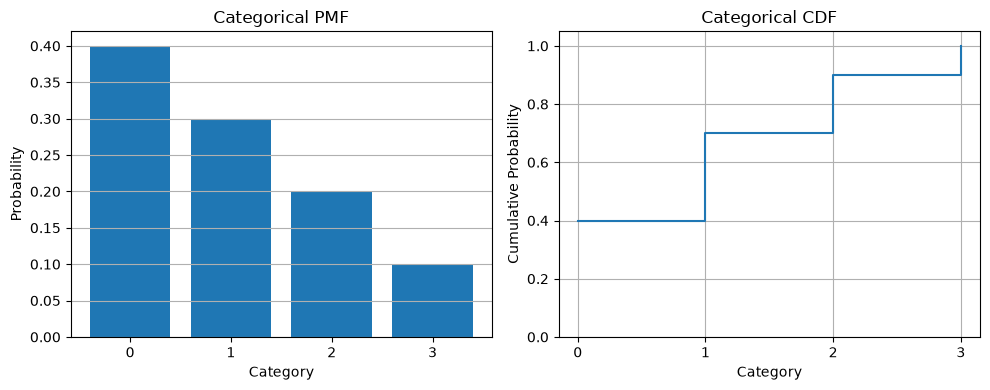

In [101]:
distribution = Categorical(
    theta=[0.4, 0.3, 0.2, 0.1]
)

distribution.plot()